In [1]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt


def temporal_average(cube1_path, cube2_path):
    # Load and process cube1
    cube1_img = nib.load(cube1_path)
    cube1_data = cube1_img.get_fdata()
    # Check if cube1 has 4 dimensions (includes time)
    if len(cube1_data.shape) == 4:
        cube1_data = np.mean(
            cube1_data[:, :, :, 20:40], axis=-1
        )  # Average over the time dimension (last dimension)
        # cube1_data = cube1_data[:,:,:,0] # take first temporal frame

    # Load and process cube2
    cube2_img = nib.load(cube2_path)
    cube2_data = cube2_img.get_fdata()
    # Check if cube2 has 4 dimensions (includes time)
    if len(cube2_data.shape) == 4:
        # Average over the time dimension (last dimension)
        cube2_data = np.mean(
            cube2_data[:, :, :, 20:40], axis=-1
        )  # Average over the time dimension (last dimension)
        # cube2_data = cube2_data[:,:,:,0] # take first temporal frame

    return cube1_data, cube2_data

In [2]:
data_path = "/Users/clairenastaskin/data/2025-05-07/sub-Forest001_ses-20250507_task-rest_acq-mcatests//"
cube1_path = os.path.join(data_path, "concatenated_quarter_top.nii.gz")
cube2_path = os.path.join(data_path, "concatenated_quarter_bottom.nii.gz")

averaged_over_time = False
if averaged_over_time:
    [cube1, cube2] = temporal_average(cube1_path, cube2_path)
else:
    cube1_img = nib.load(cube1_path)
    cube1 = cube1_img.get_fdata()

    cube2_img = nib.load(cube2_path)
    cube2 = cube2_img.get_fdata()

print(cube1.shape)
print(cube2.shape)

(153, 78, 100)
(208, 106, 118)


In [4]:
# If diverging wave

# Create cube1_reshape with same dimensions as cube2 but filled with zeros
cube1_reshape = np.zeros((cube2.shape[0], cube2.shape[1], cube2.shape[2]))

# Calculate the starting indices to center cube1 within cube1_reshape
start_x = (cube1_reshape.shape[0] - cube1.shape[0]) // 2
start_y = (cube1_reshape.shape[1] - cube1.shape[1]) // 2
start_z = (cube1_reshape.shape[2] - cube1.shape[2]) // 2

if len(cube2.shape) == 4:
    start_t = (cube1_reshape.shape[3] - cube1.shape[3]) // 2
    # Insert cube1 into the center of cube1_reshape
    cube1_reshape[
        start_x:start_x + cube1.shape[0],
        start_y:start_y + cube1.shape[1],
        start_z:start_z + cube1.shape[2],
        start_t:start_t + cube1.shape[3]
    ] = cube1
else:
    # Insert cube1 into the center of cube1_reshape (3D case)
    cube1_reshape[
        start_x:start_x + cube1.shape[0],
        start_y:start_y + cube1.shape[1],
        start_z:start_z + cube1.shape[2]
    ] = cube1

print("cube1_reshape shape:", cube1_reshape.shape)
print("Original cube1 shape:", cube1.shape)
print("cube2 shape:", cube2.shape)

cube1 = cube1_reshape


cube1_reshape shape: (208, 106, 118)
Original cube1 shape: (153, 78, 100)
cube2 shape: (208, 106, 118)


In [4]:
# # Reshape cube1 to match cube2's dimensions using interpolation
# from scipy.ndimage import zoom

# # Calculate zoom factors for each dimension
# total_dim = len(cube1.shape)  # Get number of dimensions instead of shape tuple
# zoom_factors = [cube2.shape[i] / cube1.shape[i] for i in range(total_dim)]
# # Apply interpolation to resize cube1
# cube1 = zoom(cube1, zoom_factors, order=1)  # order=1 for linear interpolation

# print("New cube1 shape:", cube1.shape)
# print("Cube2 shape:", cube2.shape)

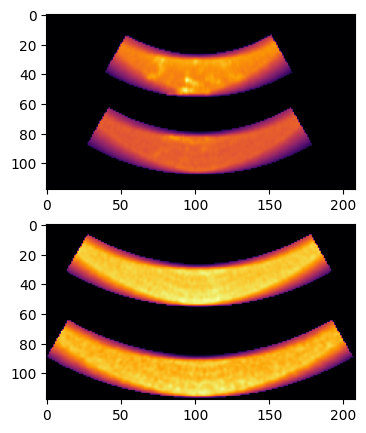

In [5]:
slicetolookat = int(cube1.shape[1]/2)  # Convert to integer for indexing

if len(cube1.shape) == 4:
    cube1tolookat = cube1[:, slicetolookat, :, 1]
    cube2tolookat = cube2[:, slicetolookat, :, 1]
else:
    cube1tolookat = cube1[:, slicetolookat, :]
    cube2tolookat = cube2[:, slicetolookat, :]


plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.imshow(cube1tolookat.T, cmap="inferno")
plt.subplot(2, 1, 2)
plt.imshow(cube2tolookat.T, cmap="inferno")
plt.show()

In [8]:
# cube1 = np.average(cube1,3)
# cube2 = np.average(cube2,3)

cube1.shape
cube2.shape

(208, 106, 118)

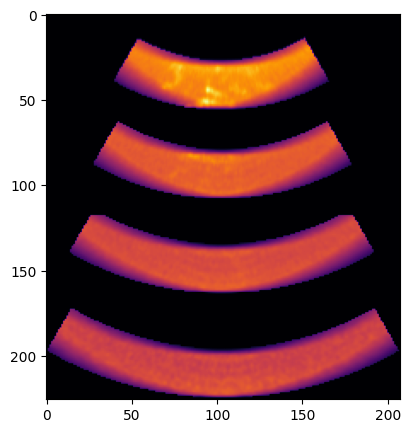

In [9]:

if len(cube1.shape) == 4:
    concatenated_cube = np.concatenate(
        (cube1[:, :,:, :], 1 * cube2[:, :, :, :]), axis=2
    )
    concatenated_cube_tolookat = concatenated_cube[:, slicetolookat, :, 1]
else:
    concatenated_cube = np.concatenate(
        (cube1[:, :, :], cube2[:, :, 10:118]), axis=2
    )
    concatenated_cube_tolookat = concatenated_cube[:, slicetolookat, :]

plt.figure(figsize=(10, 5))
# Select a specific time point (e.g. first time point) to visualize the 2D slice
plt.imshow(concatenated_cube_tolookat.T, cmap="inferno")
plt.show()
nib.save(
    nib.Nifti1Image(concatenated_cube, np.eye(4)),
    os.path.join(data_path, "concatenated_cube.nii.gz"),
)